In [4]:
#importing Librararies


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2
import random
import os
from os import listdir
from PIL import Image
from sklearn.preprocessing import label_binarize,  LabelBinarizer
from keras.preprocessing import image
#from keras.preprocessing.image import img_to_array, array_to_img
from tensorflow.keras.preprocessing.image import img_to_array
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dropout, Dense
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from keras.utils import to_categorical 

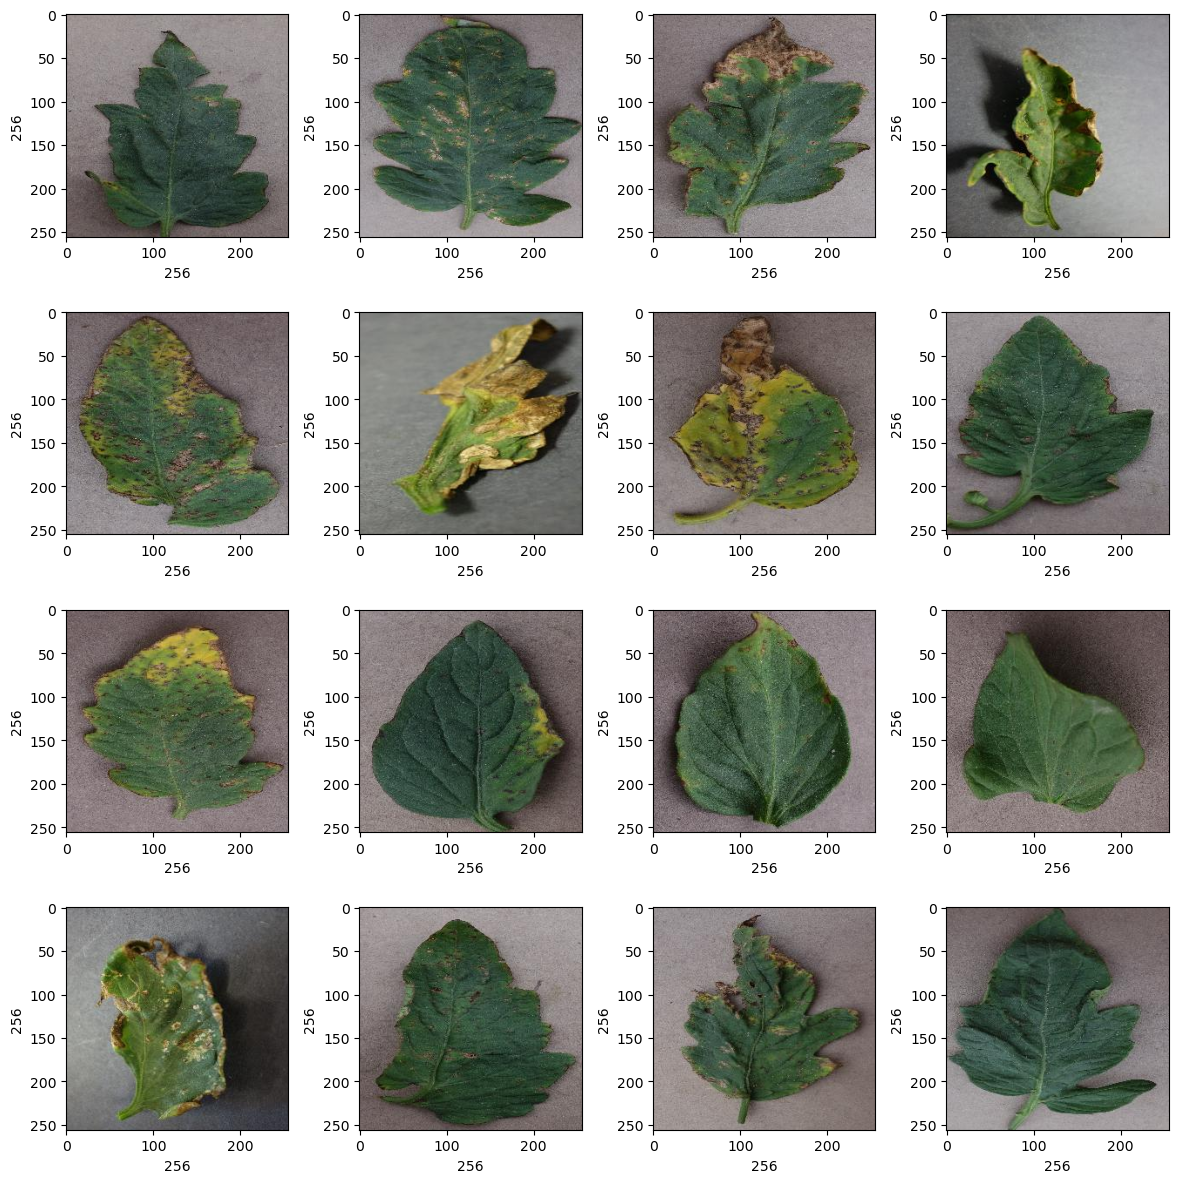

In [4]:
# Plotting 12 images to check dataset
plt.figure(figsize=(12,12))
path = "Data/Data/Tomato___Bacterial_spot"
for i in range(1,17):
    plt.subplot(4,4,i)
    plt.tight_layout()
    rand_img = imread(path +'/'+ random.choice((os.listdir(path))))
    plt.imshow(rand_img)
    plt.xlabel(rand_img.shape[0], fontsize = 10)#width of image
    plt.ylabel(rand_img.shape[1], fontsize = 10)#height of image

In [5]:
#Converting Images to array 
def convert_image_to_array(image_dir):
    try:
        image = cv2.imread(image_dir)
        if image is not None :
            image = cv2.resize(image, (256,256))  
            #image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
            return img_to_array(image)
        else :
            return np.array([])
    except Exception as e:
        print(f"Error : {e}")
        return None

In [6]:
dir = "Data/Data"
root_dir = listdir(dir)
image_list, label_list = [], []
all_labels = ['Corn-Common_rust', 'Potato-Early_blight', 'Tomato-Bacterial_spot']
binary_labels = [0,1,2]
temp = -1

# Reading and converting image to numpy array
for directory in root_dir:
  plant_image_list = listdir(f"{dir}/{directory}")
  temp += 1
  for files in plant_image_list:
    image_path = f"{dir}/{directory}/{files}"
    image_list.append(convert_image_to_array(image_path))
    label_list.append(binary_labels[temp])

In [7]:
# Visualize the number of classes count
label_counts = pd.DataFrame(label_list).value_counts()
label_counts.head()

0    300
1    300
2    300
Name: count, dtype: int64

In [8]:
image_list[0].shape

(256, 256, 3)

In [9]:
label_list = np.array(label_list)
label_list.shape

(900,)

In [10]:
#splitting

In [11]:
x_train, x_test, y_train, y_test = train_test_split(image_list, label_list, test_size=0.2, random_state = 10) 

In [12]:
x_train = np.array(x_train, dtype=np.float16) / 255.0
x_test = np.array(x_test, dtype=np.float16) / 255.0
x_train = x_train.reshape( -1, 256,256,3)
x_test = x_test.reshape( -1, 256,256,3)

In [13]:
x_train.shape

(720, 256, 256, 3)

In [14]:
x_train[0]

array([[[0.5137, 0.51  , 0.5254],
        [0.506 , 0.502 , 0.5176],
        [0.506 , 0.502 , 0.5176],
        ...,
        [0.4824, 0.4785, 0.4941],
        [0.4587, 0.4548, 0.4707],
        [0.4548, 0.451 , 0.4666]],

       [[0.5566, 0.5527, 0.569 ],
        [0.549 , 0.545 , 0.5605],
        [0.537 , 0.533 , 0.549 ],
        ...,
        [0.447 , 0.443 , 0.4587],
        [0.447 , 0.443 , 0.4587],
        [0.4666, 0.4626, 0.4785]],

       [[0.541 , 0.537 , 0.5527],
        [0.533 , 0.5293, 0.545 ],
        [0.5254, 0.5215, 0.537 ],
        ...,
        [0.4353, 0.4314, 0.447 ],
        [0.4548, 0.451 , 0.4666],
        [0.498 , 0.4941, 0.51  ]],

       ...,

       [[0.5806, 0.5767, 0.5923],
        [0.5728, 0.569 , 0.5845],
        [0.565 , 0.5605, 0.5767],
        ...,
        [0.4   , 0.4   , 0.4236],
        [0.4119, 0.4119, 0.4353],
        [0.4158, 0.4158, 0.4392]],

       [[0.5176, 0.5137, 0.5293],
        [0.5215, 0.5176, 0.533 ],
        [0.5293, 0.5254, 0.541 ],
        .

In [15]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [16]:
y_train

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [17]:
y_train.shape

(720, 3)

In [18]:
# Model 2
model = Sequential()
model.add(Conv2D(32, (3, 3), padding="same",input_shape=(256,256,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Conv2D(16, (3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(8, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.summary()

C:\Users\ASIM\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 85, 85, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 85, 85, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 42, 42, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 28224)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │         225,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 231,347 (903.70 KB)

 Trainable params: 231,347 (903.70 KB)

 Non-trainable params: 0 (0.00 B)

Next we will create a network architecture for the model. We have used different types of layers according to their features namely Conv_2d (It is used to create a convolutional kernel that is convolved with the input layer to produce the output tensor), max_pooling2d (It is a downsampling technique which takes out the maximum value over the window defined by poolsize), flatten (It flattens the input and creates a 1D output), Dense (Dense layer produce the output as the dot product of input and kernel).


In [19]:
model.compile(loss = 'categorical_crossentropy', optimizer = Adam(0.001),metrics=['accuracy'])

In [20]:
# Splitting the training data set into training and validation data sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2)

In [21]:
x_train.shape

(576, 256, 256, 3)

In [22]:
# Training the model
epochs = 5
batch_size = 128
history = model.fit(x_train, y_train, batch_size = batch_size, epochs = epochs, 
                    validation_data = (x_val, y_val),verbose = 1)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.4514 - loss: 1.2521 - val_accuracy: 0.6389 - val_loss: 0.7238
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7438 - loss: 0.6381 - val_accuracy: 0.6875 - val_loss: 0.4823
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.7502 - loss: 0.4316 - val_accuracy: 0.9097 - val_loss: 0.3493
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9261 - loss: 0.3036 - val_accuracy: 0.9375 - val_loss: 0.2835
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9604 - loss: 0.1949 - val_accuracy: 0.9583 - val_loss: 0.1818


In [23]:
#saving the weights of the model
#model.save_weights('plant_model_weights1.h5')
#model.save_weights('plant_model_weights2.weights.h5')
#model.load_weights('plant_model_weights2.weights.h5')

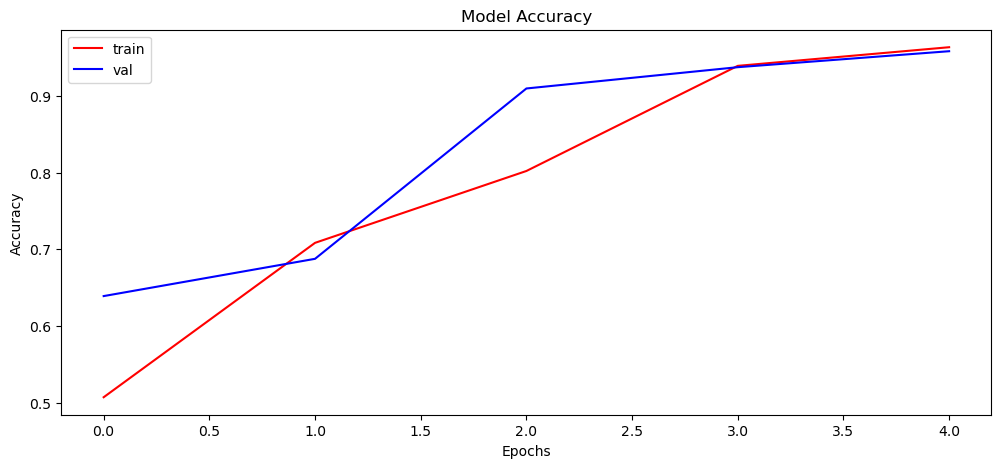

In [24]:
#Plot the training history
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()

In [25]:
print("[INFO] Calculating model accuracy")
scores = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {scores[1]*100}")

[INFO] Calculating model accuracy
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.9802 - loss: 0.1260
Test Accuracy: 97.22222089767456


In [26]:
scores

[0.13828428089618683, 0.9722222089767456]

In [27]:
y_pred = model.predict(x_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


In [29]:
from sklearn.metrics import classification_report
import numpy as np
# Predict probabilities
y_pred_probs = model.predict(x_test)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Optional: define class names
class_names = ['Corn-Common_rust', 'Potato-Early_blight', 'Tomato-Bacterial_spot']  
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

In [1]:
from sklearn.metrics import classification_report
import numpy as np
# Predict probabilities
y_pred_probs = model.predict(x_test)
# Convert predictions to class labels
y_pred = np.argmax(y_pred_probs, axis=1)
# Convert one-hot encoded y_test to labels
y_true = np.argmax(y_test, axis=1)
class_names = [
    'Corn-Common_rust',
    'Potato-Early_blight',
    'Tomato-Bacterial_spot'
]
print(classification_report(y_true, y_pred, target_names=class_names))

NameError: name 'model' is not defined

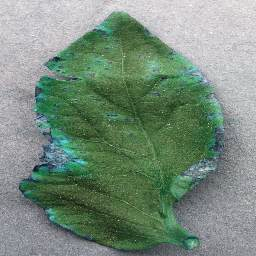

In [31]:
# Plotting image to compare
#from tensorflow.keras.preprocessing.image import array_to_image
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array

img = array_to_img(x_test[48])
img

In [33]:
# Finding max value from predition list and comaparing original value vs predicted
print("Originally : ",np.argmax(y_test[48]))
print("Predicted : ",np.argmax(y_pred[48]))

Originally :  2
Predicted :  0
